In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("dataset.csv")

df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [4]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   object 
 1   Date             1200 non-null   object 
 2   CustomerID       1200 non-null   object 
 3   Product          1200 non-null   object 
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   object 
 7   PaymentMethod    1200 non-null   object 
 8   OrderStatus      1200 non-null   object 
 9   TrackingNumber   1200 non-null   object 
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCode       891 non-null    object 
 12  ReferralSource   1200 non-null   object 
 13  TotalPrice       1200 non-null   float64
dtypes: float64(2), int64(2), object(10)
memory usage: 131.4+ KB


,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


In [5]:
df.isnull().sum()

OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

In [6]:
df["CouponCode"] = df["CouponCode"].fillna("NoCoupon")

In [7]:
df.isnull().sum()

OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["Date"] = pd.to_datetime(df["Date"])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

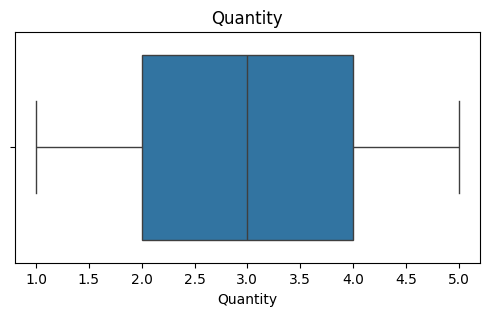

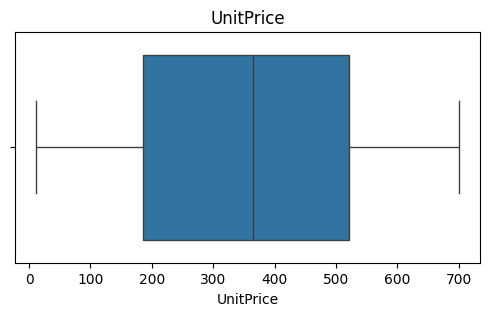

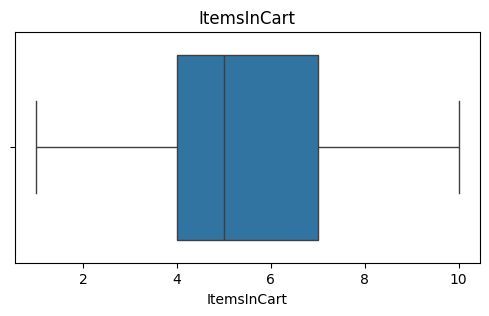

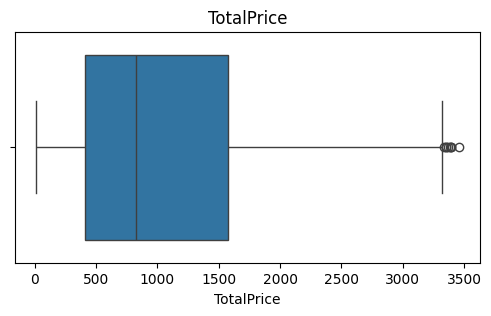

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

num_cols = ["Quantity", "UnitPrice", "ItemsInCart", "TotalPrice"]

for col in num_cols:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

In [12]:
Q1 = df["TotalPrice"].quantile(0.25)
Q3 = df["TotalPrice"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Bound:", lower)
print("Upper Bound:", upper)

outliers = df[(df["TotalPrice"] < lower) | (df["TotalPrice"] > upper)]

print("Number of Outliers:", len(outliers))

Lower Bound: -1341.4125
Upper Bound: 3330.4075
Number of Outliers: 8


In [13]:
df["TotalPrice"] = np.clip(
    df["TotalPrice"],
    lower,
    upper
)

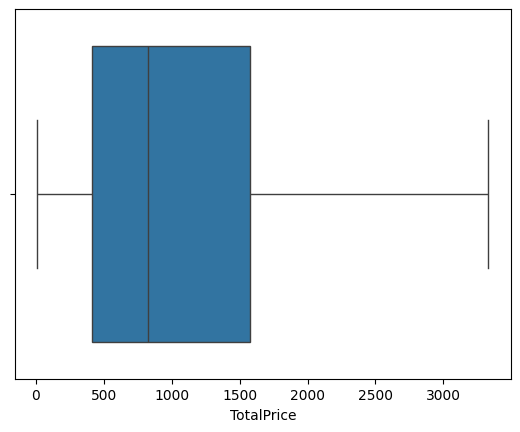

In [14]:
sns.boxplot(x=df["TotalPrice"])
plt.show()

## Feature Engineering


In [15]:
df["OrderMonth"] = df["Date"].dt.month

df["OrderDay"] = df["Date"].dt.day

In [16]:
df[["Date", "OrderMonth", "OrderDay"]].head()

,Date,OrderMonth,OrderDay
0,2023-01-04,1,4
1,2024-08-23,8,23
2,2024-02-27,2,27
3,2023-10-15,10,15
4,2025-05-08,5,8


In [17]:
df["DiscountUsed"] = (
    df["CouponCode"] != "NoCoupon"
).astype(int)

In [18]:
df[["CouponCode", "DiscountUsed"]].head(10)

,CouponCode,DiscountUsed
0,SAVE10,1
1,SAVE10,1
2,FREESHIP,1
3,SAVE10,1
4,SAVE10,1
5,SAVE10,1
6,SAVE10,1
7,FREESHIP,1
8,NoCoupon,0
9,SAVE10,1


In [19]:
df.columns

Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice',
       'OrderMonth', 'OrderDay', 'DiscountUsed'],
      dtype='object')

In [20]:
df[[
    "Quantity",
    "UnitPrice",
    "ItemsInCart",
    "TotalPrice",
    "OrderMonth",
    "OrderDay",
    "DiscountUsed"
]].corr()

,Quantity,UnitPrice,ItemsInCart,TotalPrice,OrderMonth,OrderDay,DiscountUsed
Quantity,1.000000,0.014553,0.650061,0.615362,-0.015118,0.017379,-0.041636
UnitPrice,0.014553,1.000000,0.000602,0.717232,-0.026130,0.042203,0.036048
ItemsInCart,0.650061,0.000602,1.000000,0.392579,-0.018151,-0.031994,-0.019329
TotalPrice,0.615362,0.717232,0.392579,1.000000,-0.027848,0.040793,0.007658
OrderMonth,-0.015118,-0.026130,-0.018151,-0.027848,1.000000,0.022109,0.019073
OrderDay,0.017379,0.042203,-0.031994,0.040793,0.022109,1.000000,0.016640
DiscountUsed,-0.041636,0.036048,-0.019329,0.007658,0.019073,0.016640,1.000000


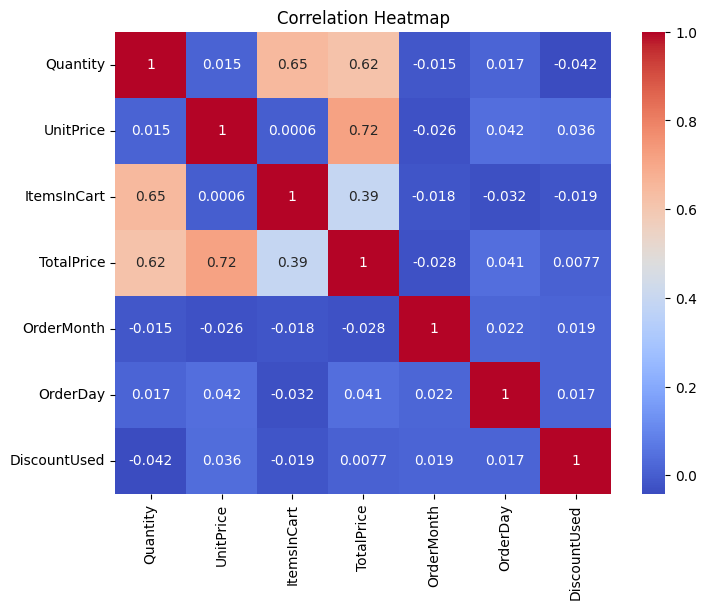

In [21]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df[[
        "Quantity",
        "UnitPrice",
        "ItemsInCart",
        "TotalPrice",
        "OrderMonth",
        "OrderDay",
        "DiscountUsed"
    ]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

In [22]:
df.to_csv("cleaned_dataset.csv", index=False)

In [23]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice,OrderMonth,OrderDay,DiscountUsed
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10,1,4,1
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70,8,23,1
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40,2,27,1
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19,10,15,1
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04,5,8,1
